   sepal length (cm)  sepal width (cm)  petal length (cm)
0                5.1               3.5                1.4
1                4.9               3.0                1.4
2                4.7               3.2                1.3
3                4.6               3.1                1.5
4                5.0               3.6                1.4
PCA Representation of 1st 5 rows of Iris Data (2 Components)
       PCA1      PCA2
0 -1.857165  0.424131
1 -1.593939 -0.714558
2 -1.951778 -0.410390
3 -1.866616 -0.661099
4 -2.016522  0.578350


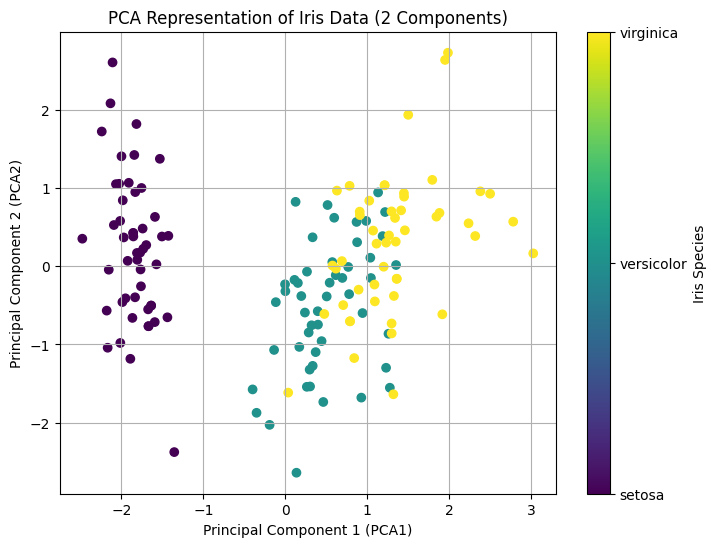


PERCENTAGE(%) OF VARIANCE:
Variance explained by PCA1: 67.3810%
Variance explained by PCA2: 30.2478%
Total variance explained by 2 components: 97.6288%


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
# Convert to pandas DataFrame for easier handling
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Take only the first three features (numerical and meet the requirement)
iris_df = iris_df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']]
print(iris_df.head(5))
# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(iris_df)

# Perform PCA
pca = PCA(n_components=2)
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)

# Create a new DataFrame for the PCA data
pca_df = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])
print('PCA Representation of 1st 5 rows of Iris Data (2 Components)')
print(pca_df.head(5))

# Plot the PCA representation
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], c=iris.target, cmap='viridis')
plt.xlabel('Principal Component 1 (PCA1)')
plt.ylabel('Principal Component 2 (PCA2)')
plt.title('PCA Representation of Iris Data (2 Components)')

# Fix: Modify the lambda function to accept two arguments (tick value and position)
plt.colorbar(label='Iris Species', ticks=np.arange(len(iris.target_names)),
             format=lambda x, pos: iris.target_names[int(x)])
plt.grid(True)
plt.show()


# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
total_explained_variance = (explained_variance[0] + explained_variance[1])*100
print(f"\nPERCENTAGE(%) OF VARIANCE:")
print(f"Variance explained by PCA1: {explained_variance[0]*100:.4f}%")
print(f"Variance explained by PCA2: {explained_variance[1]*100:.4f}%")
print(f"Total variance explained by 2 components: {total_explained_variance:.4f}%")
